# Preprocessing - PAN 2012 Training Dataset

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'config')))

from config import *
from utils import *

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import sqlite3 as sqlite
import numpy as np
import re

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [4]:
#drive.mount('/content/drive')

In [5]:
# Increases the size limit of DataFrame columns
pd.set_option('display.max_colwidth', 500)

**Connecting to SQLite**


In [6]:
connection = sqlite.connect('database.db')

print("Connection established!");

Connection established!


**Import file with sexual predators labels from training dataset**

In [7]:
SEXUAL_PREDATORS = getSexualPredatorsTrainingDataset(DRIVE_PATH)

print('Number of sexual predators:', len(SEXUAL_PREDATORS))

Number of sexual predators: 142


## Functions

In [8]:
def getDatasetInformation(df):
  print('UPDATED DATASET INFORMATION')
  print('----------------------------------------------\n')

  print('Number of conversations: ', len(df['conversation_id'].value_counts()))
  print('Number of messages: ', len(df['message']))
  print('Number of authors: ', len(df['author'].value_counts()))
  print('-')

  # Returns only messages from authors who are sexual predators
  query = '''SELECT * FROM conversations WHERE author in (%s)''' % ','.join('?'*len(SEXUAL_PREDATORS))
  aux = pd.read_sql(query, connection, params=SEXUAL_PREDATORS)

  print('Number of predatory conversations: ', len(aux['conversation_id'].unique()))
  print('Number of messages sent by sexual predators: ', len(aux['message']))
  print('Number of sexual predators: ', len(aux['author'].unique()))

In [9]:
def getConversationsWithMoreWords(df):
  aux = df.copy()
  aux['words'] = df['message'].str.count(' ') + 1

  return aux[['conversation_id', 'words', 'message']].sort_values(by=['words'], ascending = False).head(10)

## Import training dataset

In [10]:
dfBase = pd.read_csv(DRIVE_PATH + 'databases/training_balanced_full.csv', sep=';')

In [11]:
dfBase

,conversation_id,line,author,time,message
0,e621da5de598c9321a1d505ea95e6a2d,1,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,Hola.
1,e621da5de598c9321a1d505ea95e6a2d,2,0158d0d6781fc4d493f243d4caa49747,03:20,hi.
2,e621da5de598c9321a1d505ea95e6a2d,3,0158d0d6781fc4d493f243d4caa49747,03:20,whats up?
3,e621da5de598c9321a1d505ea95e6a2d,4,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,not a ton.
4,e621da5de598c9321a1d505ea95e6a2d,5,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,you?
...,...,...,...,...,...
903602,4ed6b02ae537fdfd6078597b706292a8,101,74bfc043bd5ce9c17b37ffae6e0ba2fa,22:36,oh ok
903603,4ed6b02ae537fdfd6078597b706292a8,102,8cd850ea4215ee7c4b94b6bcc0bae593,22:36,i will look for you tomorrow
903604,4ed6b02ae537fdfd6078597b706292a8,103,74bfc043bd5ce9c17b37ffae6e0ba2fa,22:36,ok
903605,4ed6b02ae537fdfd6078597b706292a8,104,8cd850ea4215ee7c4b94b6bcc0bae593,22:36,bye lissa


In [12]:
# Info

dfBase.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 903607 entries, 0 to 903606
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   conversation_id  903607 non-null  str  
 1   line             903607 non-null  int64
 2   author           903607 non-null  str  
 3   time             903607 non-null  str  
 4   message          900628 non-null  str  
dtypes: int64(1), str(4)
memory usage: 34.5 MB


In [13]:
# Number of null values by column

dfBase.isnull().sum()

conversation_id       0
line                  0
author                0
time                  0
message            2979
dtype: int64

## Preprocessing

**Creating a copy of the message column for message comparison**

In [14]:
dfBase['original_message'] = dfBase['message']

In [15]:
dfBase.head()

,conversation_id,line,author,time,message,original_message
0,e621da5de598c9321a1d505ea95e6a2d,1,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,Hola.,Hola.
1,e621da5de598c9321a1d505ea95e6a2d,2,0158d0d6781fc4d493f243d4caa49747,03:20,hi.,hi.
2,e621da5de598c9321a1d505ea95e6a2d,3,0158d0d6781fc4d493f243d4caa49747,03:20,whats up?,whats up?
3,e621da5de598c9321a1d505ea95e6a2d,4,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,not a ton.,not a ton.
4,e621da5de598c9321a1d505ea95e6a2d,5,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,you?,you?


In [16]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

903607

### Information before preprocessing

In [17]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  66927
Number of messages:  903607
Number of authors:  97689
-
Number of predatory conversations:  2016
Number of messages sent by sexual predators:  40978
Number of sexual predators:  142


### Number of words per message

In [18]:
getConversationsWithMoreWords(dfBase)

,conversation_id,words,message
207418,d6c836f0eb4b27b86eabbd8b216331e1,55855.0,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
207424,d6c836f0eb4b27b86eabbd8b216331e1,28249.0,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
301098,ef830220f9b141ef2cf3c19e345c6cac,8397.0,GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HA...
207405,d6c836f0eb4b27b86eabbd8b216331e1,5779.0,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
750718,d5e5ac5fe57798fac61ba9ca2d61c745,3081.0,"lets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play ..."
463292,71d6ec839d6fefa1d4ed0454cf34b77e,2839.0,20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on...
771481,eda07fd35ebd98b12a03687d479db47c,2784.0,° Û °° ° ° ± ÛÛÛÛßßß ßßÛÛ°±°°ÛÛÛÛÛ Û ° °\n Û ° °°°°° °° ÛÛÛÛßß Ü °°°°°ÛÛÛÛ ±Ü °\n Û °°° °° ° ÛÛÛÛß ÜÛÛÛÛÛÛ Û Û ° ° ÛÛÛ ±±Û °\n Û °°° ° ° Ûß Ûßß Û ÛÛ °Û ±ÛÛ ° ° °\n° Û ° ÛÛ ßÜÛ °° ±°ÛÛ \n Û ° ÛÛ Û ° ° ±±±±ÛÛ ° ° °\n Û ÛÛ ßÛ² °°° ...
578082,568fa57c91fe53d29dde15f5dac5f1e3,2196.0,Ask me questions and I will answer them honestly. Ask me questions and I will answer them honestly. Ask me questions and I will answer them honestly. Ask me questions and I will answer them honestly. Ask me questions and I will answer them honestly. Ask me questions and I will answer them honestly. Ask me questions and I will answer them honestly. Ask me 

### 1- Delete null messages

In [19]:
dfBase.dropna(subset=['message'], inplace=True)
dfBase.reset_index(drop=True, inplace=True)

# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

In [20]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  66914
Number of messages:  900628
Number of authors:  97671
-
Number of predatory conversations:  2015
Number of messages sent by sexual predators:  40729
Number of sexual predators:  142


### 2- Convert messages to lowercase

In [21]:
dfBase['message'] = dfBase['message'].str.lower()

In [22]:
dfBase.head()

,conversation_id,line,author,time,message,original_message
0,e621da5de598c9321a1d505ea95e6a2d,1,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,hola.,Hola.
1,e621da5de598c9321a1d505ea95e6a2d,2,0158d0d6781fc4d493f243d4caa49747,03:20,hi.,hi.
2,e621da5de598c9321a1d505ea95e6a2d,3,0158d0d6781fc4d493f243d4caa49747,03:20,whats up?,whats up?
3,e621da5de598c9321a1d505ea95e6a2d,4,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,not a ton.,not a ton.
4,e621da5de598c9321a1d505ea95e6a2d,5,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,you?,you?


In [23]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

### 3- Remove HTML character entities and \\n, \\r and \\t

#### Remove HTML character entities

In [24]:
dfBase['message'] = dfBase['message'].str.replace('&lt;', '') # <
dfBase['message'] = dfBase['message'].str.replace('&gt;', '') # >
dfBase['message'] = dfBase['message'].str.replace('&amp;', '') # &
dfBase['message'] = dfBase['message'].str.replace('&quot;', '') # " (double quotes)
dfBase['message'] = dfBase['message'].str.replace('&apos;', '') # ' (single quotes)

In [25]:
# Example

dfBase[['message', 'original_message']][18:28]

,message,original_message
18,"its nice, isnt it?","It&apos;s nice, isn&apos;t it?"
19,yeah. always enjoy visiting.,Yeah. Always enjoy visiting.
20,which island you on oahu?,Which Island you on Oahu?
21,married?,married?
22,im assuming since you went on a family trip :p,i&apos;m assuming since you went on a &apos;family&apos; trip :p
23,yeah. just found this site a few days ago.,yeah. Just found this site a few days ago.
24,"yeah, oahu.","Yeah, Oahu."
25,curious to the whole random thing,Curious to the whole &quot;random thing&quot;
26,"pretty crazy the individuals you meet, isnt it?","Pretty crazy the individuals you meet, isn&apos;t it?"
27,its been eye opening for sure.,It&apos;s been eye opening for sure.


#### Remove \\n, \\r e \\t

In [26]:
i=0
j=0
for message in dfBase['message']:
  m = re.search(r'\\n', message)
  n = re.search(r'\n', message)
  if m:
    i=i+1

  if n:
    j=j+1

print('Number of \\\\n:', i)
print('Number of \\n:', j)

Number of \\n: 192
Number of \n: 1687


**Replaces \n, \r and \t with empty space because some words have no space between them and punctuation**

In [27]:
dfBase['message'] = dfBase['message'].str.replace(r'\\n|\\r|\\t', ' ', regex=True)
dfBase['message'] = dfBase['message'].str.replace(r'\n|\r|\t', ' ', regex=True)

In [28]:
# Example

dfBase[dfBase['conversation_id'] == '65ed509ed4f8637d1dd5cef866b1ba38'][['message', 'original_message']][6:15]

,message,original_message
240488,i have,i have
240489,sorry,sorry
240490,torin: vim regexp's predate a lot of stuff.,Torin: vim regexp's predate a lot of stuff.
240491,torin: one of them is the definition of ' ',Torin: one of them is the definition of '\n'
240492,hmm,hmm
240493,"in vim is \0 in c, or nul","\n in vim is \0 in C, or NUL"
240494,i want a new line,i want a new line
240495,is 'newline',\r is 'newline'
240496,ohh,ohh


In [29]:
# Example

dfBase[dfBase['conversation_id'] == 'd6c836f0eb4b27b86eabbd8b216331e1'][['message', 'original_message']][0:1]

,message,original_message
206772,ficial messages from omegle will not be sent with the label stranger:. strangers claiming to represent omegle are lying.youre now chatting with a random stranger. say hi! official messages from omegle will not be sent with the label stranger:. strangers claiming to represent omegle are lying.youre now chatting with a random stranger. say hi! official messages from omegle will not be sent with the label stranger:. strangers claiming to represent omegle are lying.youre now chatting with a rand...,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...


In [30]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

### 4- Remove URLs

In [31]:
i=0
for message in dfBase['message']:
  m = re.search('https?:\/\/\S+|www\.\S+', message)
  if m:
    i=i+1
    #print(m.group(0))

print('Number of URLs:', i)

<>:3: SyntaxWarning: invalid escape sequence '\/'
<>:3: SyntaxWarning: invalid escape sequence '\/'
C:\Users\mathe\AppData\Local\Temp\ipykernel_19956\2001534565.py:3: SyntaxWarning: invalid escape sequence '\/'
  m = re.search('https?:\/\/\S+|www\.\S+', message)


Number of URLs: 26878


In [32]:
# tratamento para as URLs

def find_links(text):
  # Corrected regex: \\ matches a literal backslash, - at the end matches a literal hyphen
  return re.findall(r'(?:https?://|www\.)[\w/\\\?=%.\-]+(?:\.[\w/\\\&\?=%.\-]+)*', text)

def normalize_url(url):
  if (find_links(url) == False):
    return url
  url = split_dot_domain(url)
  url = remove_http(url)
  url = split_dir_route(url)
  url = remove_www(url)
  url = split_hyphen_domain(url)
  return url

def split_dot_domain(text):
  return text.replace('.', ' ')

def split_hyphen_domain(text):
  return text.replace('-', ' ')

def remove_http(text):
  return text.replace('https://', '').replace('http://', '')

def split_dir_route(text):
  return text.replace('/', ' ')

def remove_www(text):
  return text.replace('www', '')

In [33]:
dfBase['message'] = dfBase['message'].apply(normalize_url)

In [34]:
# Example

dfBase[dfBase['conversation_id'] == 'aa7fe505c5ce8ea125c3c146224efda5'][['message', 'original_message']][9:28]

,message,original_message
42377,lists w3 org archives member w3c html cg 2007octdec 0174 html,-- http://lists.w3.org/Archives/Member/w3c-html-cg/2007OctDec/0174.html
42378,or to even consider that?,or to even consider that?
42379,or to come up with some compromise?,or to come up with some compromise?
42380,how is any of this consensus building?,how is any of this consensus building?
42381,"i don't know enough context, but i read feel obligation not feel like","I don't know enough context, but I read &quot;feel obligation&quot; not &quot;feel like&quot;"
42382,i've seen them ask members who asked for charter changes what changes they want,I've seen them ask Members who asked for charter changes what changes they want
42383,"not the smartest thing to put it to the vote if there are some process rules that oblige them, granted","not the smartest thing to put it to the vote if there are some process rules that oblige them, granted"
42384,i haven't seem them talk to members who oppose charter changes to explain their reasoning,I haven't seem them talk to Members who oppose charter changes to explain their reasoning
42385,i don't believe any process rule obliges them to recharter,I don't believe any process rule obliges them to recharter
42386,and i don't believe that is their claim,and I don't believe that is their claim


In [35]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

### 5- Remove punctuation, unknown and accented letters

**Replaces punctuation with space because some words have no space between them and punctuation**

**Only single quotes don't need space**

In [36]:
dfBase['message'] = dfBase['message'].str.replace('\'', '')
dfBase['message'] = dfBase['message'].str.replace('[^a-z0-9\s]', ' ', regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mathe\AppData\Local\Temp\ipykernel_19956\2683722857.py:2: SyntaxWarning: invalid escape sequence '\s'
  dfBase['message'] = dfBase['message'].str.replace('[^a-z0-9\s]', ' ', regex=True)


In [37]:
# Example

dfBase[dfBase['conversation_id'] == '93e065929a4140689227b427415f5abb'][['message', 'original_message']][40:]

,message,original_message
43440,rickrolled,rickrolled
43441,never gonna ...,"…………………………………………. …………………………….-~~”””’~~–,,_\r\n………………………………………….. …………………………….,-~”-,:::::::::::::::::::”-,\r\n………………………………………….. ………………………..,~”::::::::’,::::::: :::::::::::::|’,\r\n………………………………………….. ………………………..|::::::,-~”’___””~~–~”’:}\r\n………………………………………….. ………………………..’|:::::|: : : : : : : : : : : : : :\r\n………………………………………….. ………………………..|:::::|: : :-~~—: : : —–: |\r\n………………………………………….. ……………………….(_”~-’: : : : : : : : :\r\n………………………………………….. ………………………..”’~-,|: : : : : : ~—’: : : :,’–never gon..."


In [38]:
# Example

dfBase[dfBase['conversation_id'] == '65bbcf71365f6580e4ddc5f26e039c51'][['message', 'original_message']]

,message,original_message
59727,hi,Hi!
59728,its impolite not to return greetings,It&apos;s impolite not to return greetings.
59729,heil hitler ...,_______________HEIL HITLER______________ \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n????????????????????????????????? \n?????????????????????...


In [39]:
# Example

dfBase[dfBase['conversation_id'] == '2f07eda4b81036ae3aa5be01ddc7515b'][['message', 'original_message']][5:15]

,message,original_message
84249,15 female i dont wanna know where youre from so why do you wanna know mine,"15, female. i don&apos;t wanna know where you&apos;re from, so why do you wanna know mine."
84250,,---------------------
84251,d,;D
84252,,[:
84253,,---------------------------
84254,im 15 male from germany,im 15 male from germany
84255,,____________________________________________________________________
84256,do u have msn,do u have msn
84257,,?
84258,p,:P


In [40]:
# Example

dfBase[dfBase['conversation_id'] == 'bc2043c280dcf4bcd067fe13f8ca7555'][['message', 'original_message']][5:20]

,message,original_message
5519,,ÔÓ ÚÓ˜ÌÓ ÛÚ?Â ?Â ?‡Á·Â?‡
5520,lord sithius blagodarsko,Lord_Sithius blagodarsko
5521,luda glawa edno diablo,Luda_Glawa: edno diablo ?
5522,deathmaster,"[Deathmaster], ÒÚ‡‚‡"
5523,,Ó·‡˜Â ‰‡È ‰‡ ÒÂ Ó·Á‡ÎÓÊËÏ Ô?Â‰Ë ÚÓ‚‡
5524,,??
5525,,ÒÔÓ?Â‰ ÚÂ· ÒÎÂ‰ ÍÓÎÍÓ ‚?ÂÏÂ ?Â Á‡·ËÂ Ò??‚??‡?
5526,,:-)))
5527,20,20 ÏËÌÛÚË?
5528,,Ì?Ï‡ ‰‡ Á‡·ËÂ


In [41]:
# Example

dfBase[dfBase['conversation_id'] == 'eda07fd35ebd98b12a03687d479db47c'][['message', 'original_message']]

,message,original_message
768862,...,° Û °° ° ° ± ÛÛÛÛßßß ßßÛÛ°±°°ÛÛÛÛÛ Û ° °\n Û ° °°°°° °° ÛÛÛÛßß Ü °°°°°ÛÛÛÛ ±Ü °\n Û °°° °° ° ÛÛÛÛß ÜÛÛÛÛÛÛ Û Û ° ° ÛÛÛ ±±Û °\n Û °°° ° ° Ûß Ûßß Û ÛÛ °Û ±ÛÛ ° ° °\n° Û ° ÛÛ ßÜÛ °° ±°ÛÛ \n Û ° ÛÛ Û ° ° ±±±±ÛÛ ° ° °\n Û ÛÛ ßÛ² °°° ...
768863,ok,ok
768864,,?
768865,n1,n1


In [42]:
# Example

dfBase[dfBase['conversation_id'] == '9d9909eafba749e02d94aca80e18a298'][['message', 'original_message']]

,message,original_message
64046,,"________ ________ _________ ____________;_\n - ______ \ - ______ \ / _____ //. . ._______/\n / / / // / / //_/ / // ___ /\n / / / // / / / .-&apos;//_/|_/,-&apos;\n / / / // / / / .-&apos;.-&apos;\n / / / // / / / / /\n / / / // / / / / /\n/ /_____/ // /_____/ / / /\n\________- \________- /_/"
64047,are u turk sh horny g rl,are u turk?sh horny g?rl?
64048,fuck,FUCK
64049,,"________ ________ _________ ____________;_\n - ______ \ - ______ \ / _____ //. . ._______/\n / / / // / / //_/ / // ___ /\n / / / // / / / .-&apos;//_/|_/,-&apos;\n / / / // / / / .-&apos;.-&apos;\n / / / // / / / / /\n / / / // / / / / /\n/ /_____/ // /_____/ / / /\n\________- \________- /_/"


In [43]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

### 6- Remove empty spaces in sequence

In [44]:
i=0
for message in dfBase['message']:
  m = re.search('\s{2,}', message)
  if m:
    i=i+1

print('Number of messages with more than 2 spaces in sequence:', i)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mathe\AppData\Local\Temp\ipykernel_19956\3872551768.py:3: SyntaxWarning: invalid escape sequence '\s'
  m = re.search('\s{2,}', message)


Number of messages with more than 2 spaces in sequence: 312405


In [45]:
# Example of conversation with many spaces

dfBase[dfBase['conversation_id'] == '67a80b498aa446a0ff72ff8448f6ec5e']['message']

184173                                                                             gmail   inbox for  email  
184174                                                                                  you have 20 new mails
184175                                                                                                       
184176                            sl   subject                                                  author       
184177                                                                                                       
184178                   0    njoi                                                     anagha missin         
184179                       1        happy friendship day                                 neeraj            
184180                                                                     traceback  most recent call last  
184181                                                                     file check gmail py  line 50  in  
184182    

In [46]:
# Remove spaces in sequence
dfBase['message'] = dfBase['message'].str.replace('\s{2,}', ' ', regex=True)

# Remove spaces at the beginning and end
dfBase['message'] = dfBase['message'].apply(lambda m: m.strip())

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mathe\AppData\Local\Temp\ipykernel_19956\3385308571.py:2: SyntaxWarning: invalid escape sequence '\s'
  dfBase['message'] = dfBase['message'].str.replace('\s{2,}', ' ', regex=True)


In [47]:
# Example

dfBase[dfBase['conversation_id'] == '67a80b498aa446a0ff72ff8448f6ec5e']['message']

184173                                                                               gmail inbox for email
184174                                                                               you have 20 new mails
184175                                                                                                    
184176                                                                                   sl subject author
184177                                                                                                    
184178                                                                                0 njoi anagha missin
184179                                                                       1 happy friendship day neeraj
184180                                                                     traceback most recent call last
184181                                                                      file check gmail py line 50 in
184182                               

In [48]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

### 7- Delete empty messages

In [49]:
print('Number of empty messages:', len(dfBase[dfBase['message'] == '']))

Number of empty messages: 23007


In [50]:
# 50 first examples

dfBase[dfBase['message'] == ''][['conversation_id', 'message', 'original_message']].head(50)

,conversation_id,message,original_message
138,2c8125f8376aa2515c19222ba4213c28,,?
176,7de43ad0a0a236d48a580c411eb7feae,,?
411,dd6f7c7ef644abca600d28b5afd8c191,,;)
488,b073155c5f4c846b2757543a60826d81,,.
518,fc77b9ed8d13697e8deea79de0b4df23,,:-*
582,fc77b9ed8d13697e8deea79de0b4df23,,:-:-
597,fc77b9ed8d13697e8deea79de0b4df23,,:-:-:-:-*
603,fc77b9ed8d13697e8deea79de0b4df23,,:-*
734,9f8d1a7c70b4784070070b886baeba52,,?
751,8c3f1c715570a7af14a69cce09a045d6,,?


**Replace empty spaces with null**

In [51]:
dfBase['message'].replace('', np.nan, inplace=True)

C:\Users\mathe\AppData\Local\Temp\ipykernel_19956\1213569535.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dfBase['message'].replace('', np.nan, inplace=True)


0                                 hola
1                                   hi
2                             whats up
3                            not a ton
4                                  you
                      ...             
900623                           oh ok
900624    i will look for you tomorrow
900625                              ok
900626                       bye lissa
900627                        bye jake
Name: message, Length: 900628, dtype: str

In [52]:
# Number of null values by column

dfBase.isnull().sum()

conversation_id     0
line                0
author              0
time                0
message             0
original_message    0
dtype: int64

In [53]:
# Example of messages sent by sexual predators that will be deleted

dfBase[(dfBase['message'].isnull()) & (dfBase['author'] == '6f35a1f69fd4ae82056e4bc6a8a84575')]

,conversation_id,line,author,time,message,original_message


In [54]:
# Example of messages sent by sexual predators that will be deleted

dfBase[(dfBase['message'].isnull()) & (dfBase['author'] == 'c62283536cf6261e5ffbcb323c8a2571')]

,conversation_id,line,author,time,message,original_message


**Delete messages that are null**

In [55]:
dfBase.dropna(subset=['message'], inplace=True)
dfBase.reset_index(drop=True, inplace=True)

# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

In [56]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  66914
Number of messages:  900628
Number of authors:  97671
-
Number of predatory conversations:  2015
Number of messages sent by sexual predators:  40729
Number of sexual predators:  142


### 8- Remove repeated letters in a word

In [57]:
"""
Adapted from https://github.com/biemt-pesc-coppe-ufrj/exemplosXexeo/blob/8438dcfd5ee5594123be1bcaa52e30a18c53e425/Norvig%20Simples/bimt_spell.py

"""

def removeRepeatedLetters(word):
  "Remove repeated letters in a word."

  return re.sub('([a-zA-Z])(?=(\\1){2})', '', word)

In [58]:
dfBase['message'] = dfBase['message'].apply(lambda m: removeRepeatedLetters(m))

In [59]:
# Example

dfBase[dfBase['conversation_id'] == 'fbf93ab0370b314128ab9d62ec6b56a2'][['message', 'original_message']]

,message,original_message
102,hi,hi
103,asl,asl
104,hi,Hi
105,helloo,hellloooo


In [60]:
dfBase[dfBase['conversation_id'] == '722b7a3329ddd4549c158370d53613f9'][['message', 'original_message']][25:]

,message,original_message
12318,yes bruva,YES BRUVA
12319,i dnt speak it fluently,i dnt speak it fluently
12320,hhaa,hhaaa
12321,thatscos yu dont speak it at all,thatscos yu dont speak it at all
12322,im watchin sunday best its halarious,im watchin sunday best its halarious
12323,haha,haha
12324,i dont give a shit you fake,I DONT GIVE A SHIT YOU FAKE
12325,ffaakkerr,ffffaaakkkkerrrr


In [61]:
dfBase[dfBase['conversation_id'] == '01b187e109530bfa641cc1e16497e37c'][['message', 'original_message']][10:25]

,message,original_message
25625,we are soo useless,we are sooooooooo useless
25626,speak for yourself i could donate my liv never mind,"speak for yourself, I could donate my liv... never mind"
25627,come on teh warez download phast0r,come on teh warez download phast0r
25628,gasp,gasp
25629,anyone got crackz for openbsd 3 9,anyone got crackz for OpenBSD 3.9 ?
25630,d,:D
25631,scp teh good stuff email,scp teh-good-stuff <email/>
25632,,;)
25633,,:)
25634,hmm are there different versions whatever of the ports tree,"Hmm, are there different versions/whatever of the ports tree?"


In [62]:
dfBase[dfBase['conversation_id'] == 'aa9d8c30d9f2f20bbf28d56c894dfa88'][['message', 'original_message']][120:]

,message,original_message
26182,wee,weeeeee
26183,im happy,im happy
26184,ru,ru?
26185,hlo,hlo?
26186,ru there,ru there?
26187,i gotta p brb,i gotta p brb
26188,kay bak,kay bak
26189,heelloo,heeellllooooooooooooo
26190,shawn,shawn
26191,,:(


In [63]:
dfBase[dfBase['conversation_id'] == '6b0fbc8a53e4c63c092cc9d0bd0b463a'][['message', 'original_message']][33:]

,message,original_message
40478,ar u there,ar u there..?
40479,helloo,hellloooooooo
40480,hey liu,hey liu
40481,hahahh,hahahh
40482,helloo,hellooo
40483,helloo,hellooo
40484,heklloo,heklllooo
40485,helloo,hellooo
40486,helloo,helloooo
40487,helloo,hellooo


### 9- Remove repeated words in sequence

In [64]:
i=0
for message in dfBase['message']:
  m = re.search(r'\b(.+)\s+\1\b', message)
  if m and m.group(0).strip():
    i=i+1
    #print(m.group(0))

print('Number of messages with some repeated word::', i)

Number of messages with some repeated word:: 20157


In [65]:
# Remove repeated words
dfBase['message'] = dfBase['message'].apply(lambda m: removeRepeatedWordsInSequence(m))

# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

900628

In [66]:
# Example

dfBase[dfBase['conversation_id'] == 'd6c836f0eb4b27b86eabbd8b216331e1'][['message', 'original_message']][0:6]

,message,original_message
206772,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
206773,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
206774,moii ooks suomest,moiiii ooks suomest ?
206775,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
206776,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...
206777,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Strange

In [67]:
# Example

dfBase[dfBase['conversation_id'] == 'ef830220f9b141ef2cf3c19e345c6cac'][['message', 'original_message']]

,message,original_message
299921,hey,hey
299922,asl,asl?
299923,gingers do have souls,GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HA...


In [68]:
# Example

dfBase[dfBase['conversation_id'] == '5c985f8a688a3e2fb6d310077dcccbcd'][['message', 'original_message']][10:18]

,message,original_message
22558,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!
22559,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!
22560,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger....
22561,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!
22562,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger....
22563,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger....
22564,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger....
22565,youre now chatting with a random stranger say hi,You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!You&apos;re now chatting with a random stranger. Say hi!


In [69]:
# Example

dfBase[dfBase['conversation_id'] == 'ac7dc47cf0b5c2b27bb3dd965d62322a'][['message', 'original_message']]

,message,original_message
447743,hey,hey
447744,asl,asl?
447745,pudi,PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI P...
447746,pudi,PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI PUDI P...


**Comparing amount of words before and after removing repeated words**

In [70]:
df = dfBase.copy()
df['words_before'] = df['original_message'].str.count(' ') + 1
df['words_after'] = df['message'].str.count(' ') + 1

df[['words_before', 'original_message', 'words_after', 'message']].sort_values(by=['words_before'], ascending = False).head(10)

,words_before,original_message,words_after,message
206791,55855,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...,47,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying
206797,28249,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...,47,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying
299923,8397,GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HAVE SOULS! GINGERS DO HA...,4,gingers do have souls
206778,5779,ficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represent Omegle are lying.You&apos;re now chatting with a random stranger. Say hi!\nOfficial messages from Omegle will not be sent with the label &apos;Stranger:&apos;. Strangers claiming to represe...,48,ficial messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying youre now chatting with a random stranger say hi official messages from omegle will not be sent with the label stranger strangers claiming to represent omegle are lying vvyguihjkroigfdvivgyu
748117,3081,"lets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play explosion knight quest seven, i go first and use lazer blast, 10 damagelets play ...",29,lets play explosion knight quest seven i go first and use lazer blast 10 damagelets play explosion knight quest seven i go first and use lazer blast 10 damage
461750,2839,20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet on cam20 m us lookin for girls to show their feet o

### Information after preprocessing

In [71]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  66914
Number of messages:  900628
Number of authors:  97671
-
Number of predatory conversations:  2015
Number of messages sent by sexual predators:  40729
Number of sexual predators:  142


### Number of words per message

In [72]:
getConversationsWithMoreWords(dfBase)

,conversation_id,words,message
280176,3c98f24025742ea1d9ea8b3990071732,2000,declining productivity an artificially high fixed exchange rate between the ruble and foreign currencies to avoid public turmoil and a chronic fiscal deficit were the background to the meltdown the economic cost of the first war in chechnya that is estimated at 5 billion not including the rebuilding of the ruined chechen economy was also a cause of the crisis in the first half of 1997 the russian economy showed some signs of improvement however soon after this the problems began to gradually...
204329,06649fab7088fa8a4c58ccd27ac4d3d8,1410,the city hung under a pall of grey the roiling mass of cloud above and distant thunder promising a storm the streets were empty with the exception of the few huddled figures going about their late afternoon business from the hills to the east the all encompassing fog began to descend making its way through the latticework of streets tendrils of mist inquisitively groping at the forms of buildings and unlit street lamps the insistent wind pulls the fog towards the outskirts of the city to a h...
101837,9862471a316571ab4bad3ae68cf72c5e,1071,what home computing technology spreadsheets about com spreadsheets the basics formulas and functions advanced share print free spreadsheets newsletter discuss in my forum how to use excel tutorials for beginners guide to excel 2003 by ted french about com guide see more about beginners guide to excel how to use excel sponsored links exceltodays market news opinions by market experts live market updatesmoneycontrol com excel charts in secondsautomatically summarize and assign data and reuse c...
204154,75fef10a08b0ce3b7cfc95348f9ae300,877,ebenin am na benchten gelip katk da buluniim ekoslovakyal la t ramad klar m z n ebesinin k ll a amc n ortalar ndan sa ve sola a yapm dillerini sikti imin evlad n ta annesini b yle tavana asiim ut saatiyle ma saati aras ndaki fark boyunca anneni atur utur k z arkada nla beraber g t rr ken kim engelleyebilir ki ebenin am n dikine sikerim g zl n sap n am na kodumun a t rma a z n skerim y z n pi g t n amc kba l anzorotun antilop ta aa yalam versiyonu seni taburenin zerine kart p berber ra yla be...
149383,1e27624c3009e13ab708d46babf06fc7,784,stranger hi you stranger hey you im a horny girl please me you my name is anna stranger uhm sure stranger my names rei stranger nice to fuck you ok d you i would love that stranger how big are your tits you medium size stranger they can fit stranger im into kinky shit is that ok you yes d you i dont mind you i saw my sister fuck her bf and i got horny stranger wow youre one slutty chick you lol thanks d you also bi stranger thats extremely slutty stranger you be lovin my cock long time you a...
582444,05f5b2119260313889c7b87d52bd1381,691,given the existence as uttered forth in the public works of puncher and wattmann of a personal god quaquaquaqua with white beard quaquaquaqua outside time without extension who from the heights of divine apathia divine athambia divine aphasia loves us dearly with some exceptions for reasons unknown but time will tell and suffers like the divine miranda with those who for reasons unknown but time will tell are plunged in torment plunged in fire whose fire flames if that continues and who can ...
145246,88b4a0b1c954f4f43c835c32e2d756de,639,stranger i am lord voldemort you ok stranger what is your name you my name is karen and im a professional psychologist stranger is that a muggle name stranger and a muggle job stranger you filthy mudblood stranger avada kedavra you were here today to talk about you thinking that you can do magic stranger i can do magic you and killing random eople stranger ive killed many random people via magic you damn i cant even solve this stranger the avada kedavra curse is my faithful friend you its ba...
400939,7c9e28cbc41d185e1fc31bbd577d1273,616,hello do you know jesus as your personal savior may the lord bless you with this ability from him and only him rem

### Number of authors per conversation

<Axes: ylabel='Frequency'>

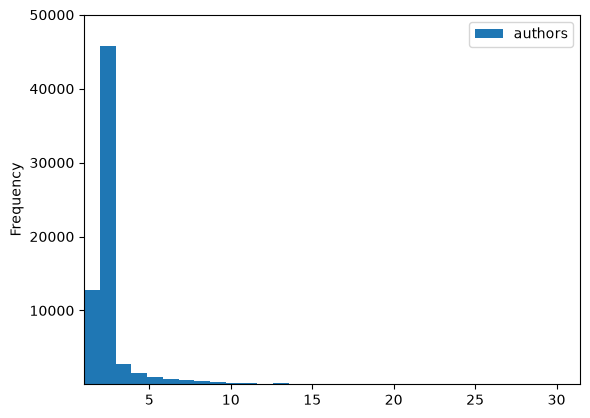

In [73]:
# Number of authors per conversation

query = '''SELECT conversation_id, count(distinct(author)) as authors
           FROM conversations
           GROUP BY conversation_id
           ORDER BY authors desc;'''

df = pd.read_sql(query, connection)
df.plot.hist(bins=30, ylim=(1,50000), xlim=(1))

### Number of messages per conversation

<Axes: ylabel='Frequency'>

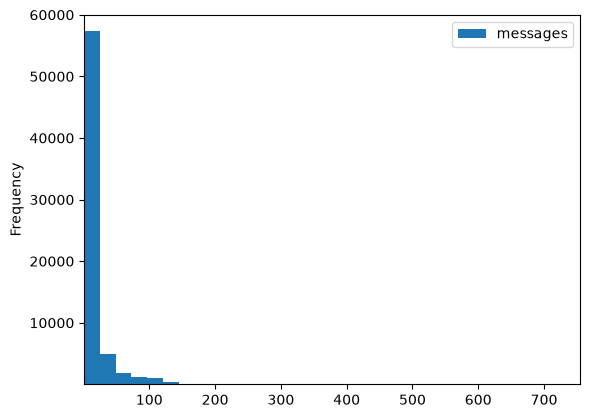

In [74]:
# Number of messages per conversation

query = '''SELECT conversation_id, count(distinct(message)) as messages
           FROM conversations
           GROUP BY conversation_id
           ORDER BY messages desc;'''

df = pd.read_sql(query, connection)
df.plot.hist(bins=30, ylim=(1,60000), xlim=(1))

### WordCloud

#### WordCloud of all messages

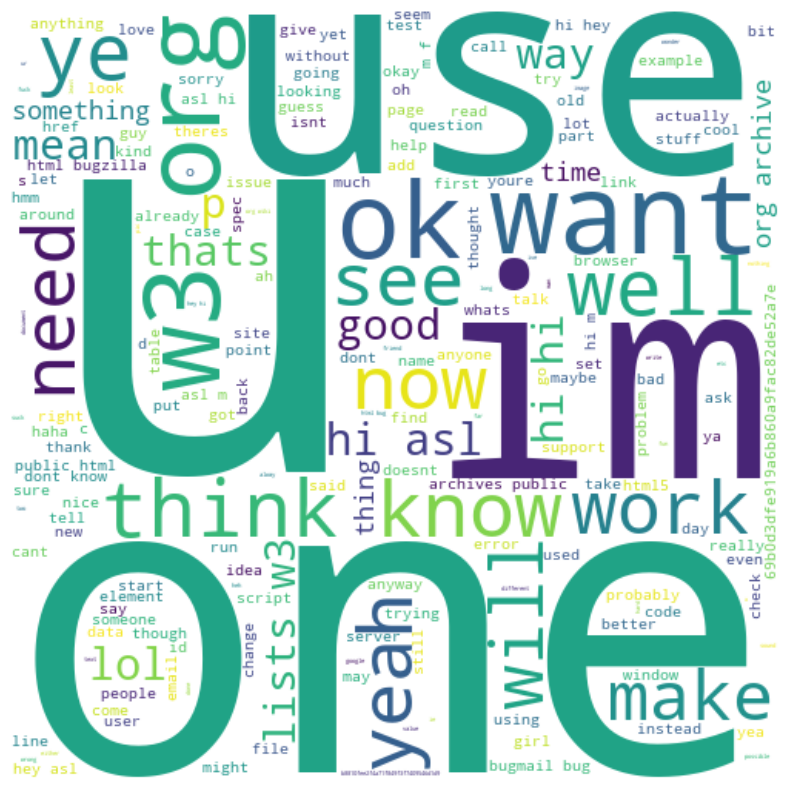

In [75]:
text = " ".join(message for message in dfBase['message'])

wordcloud = WordCloud(width=500, height=500, background_color="white").generate(text)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Saving image
wordcloud.to_file("wordcloud.png")

#### WordCloud of sexual predators messages

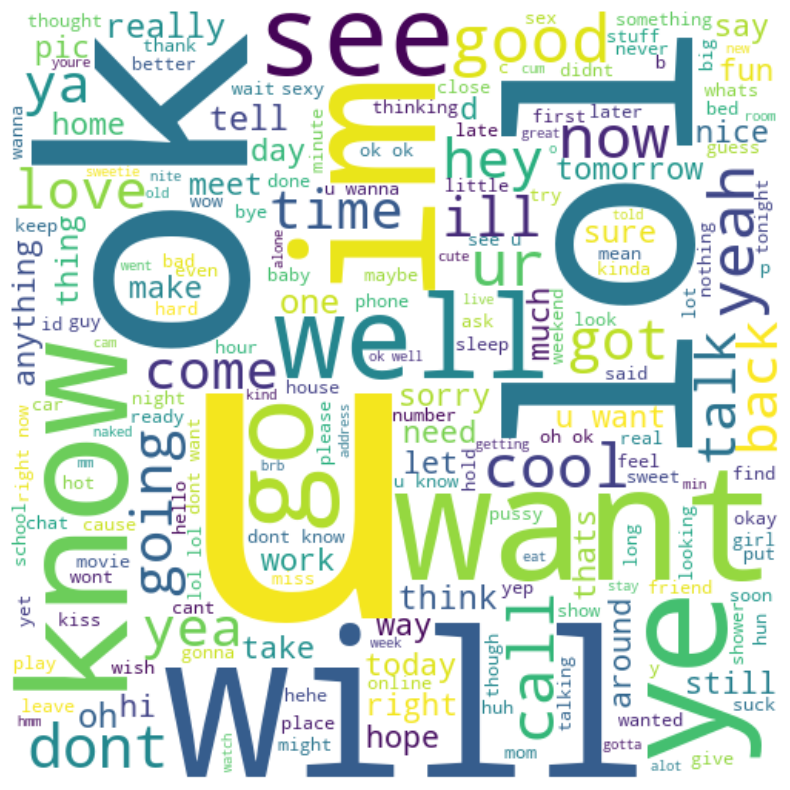

In [76]:
# Returns only messages from authors who are sexual predators
query = '''SELECT * FROM conversations WHERE author in (%s)''' % ','.join('?'*len(SEXUAL_PREDATORS))
aux = pd.read_sql(query, connection, params=SEXUAL_PREDATORS)

text = " ".join(message for message in aux['message'])

wordcloud = WordCloud(width=500, height=500, background_color="white").generate(text)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Saving image
wordcloud.to_file("wordcloud_predators.png")

### Save preprocessed dataset

In [77]:
# Dropping column "original_message"

dfBase.drop('original_message', inplace=True, axis=1)

#### Save predatory conversations dataset

In [78]:
dfPredatoryConversations = dfBase.copy()

# Returns only messages from authors who are sexual predators
query = '''SELECT * FROM conversations WHERE author in (%s)''' % ','.join('?'*len(SEXUAL_PREDATORS))
aux = pd.read_sql(query, connection, params=SEXUAL_PREDATORS)

predatoryConversations = aux['conversation_id'].unique()

# Adding column "predatory_conversation" with value False initially
# When the conversation is a predatory conversation, the label will be changed to True

dfPredatoryConversations = dfPredatoryConversations.assign(predatory_conversation = False)

for predatoryConversation in predatoryConversations:
  dfPredatoryConversations.loc[(dfPredatoryConversations['conversation_id'] ==  predatoryConversation), ['predatory_conversation']] = True

In [79]:
dfPredatoryConversations

,conversation_id,line,author,time,message,predatory_conversation
0,e621da5de598c9321a1d505ea95e6a2d,1,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,hola,False
1,e621da5de598c9321a1d505ea95e6a2d,2,0158d0d6781fc4d493f243d4caa49747,03:20,hi,False
2,e621da5de598c9321a1d505ea95e6a2d,3,0158d0d6781fc4d493f243d4caa49747,03:20,whats up,False
3,e621da5de598c9321a1d505ea95e6a2d,4,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,not a ton,False
4,e621da5de598c9321a1d505ea95e6a2d,5,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,you,False
...,...,...,...,...,...,...
900623,4ed6b02ae537fdfd6078597b706292a8,101,74bfc043bd5ce9c17b37ffae6e0ba2fa,22:36,oh ok,True
900624,4ed6b02ae537fdfd6078597b706292a8,102,8cd850ea4215ee7c4b94b6bcc0bae593,22:36,i will look for you tomorrow,True
900625,4ed6b02ae537fdfd6078597b706292a8,103,74bfc043bd5ce9c17b37ffae6e0ba2fa,22:36,ok,True
900626,4ed6b02ae537fdfd6078597b706292a8,104,8cd850ea4215ee7c4b94b6bcc0bae593,22:36,bye lissa,True


In [80]:
# Number of tuples for each value of the label 'predatory_conversation'

dfPredatoryConversations['predatory_conversation'].value_counts()

predatory_conversation
False    821804
True      78824
Name: count, dtype: int64

In [81]:
# Saving predatory conversations dataset

dfPredatoryConversations.to_csv(DRIVE_PATH + 'databases/training_predatoryconversations_preprocessed_url_altered_full.csv', index=False, header=True, sep=';')

#### Save predators dataset

In [82]:
dfPredators = dfBase.copy()

# Adding column "predator" with value False initially
# When the author is a sexual predator, the label will be changed to True

dfPredators = dfPredators.assign(predator = False)

for predator in SEXUAL_PREDATORS:
  dfPredators.loc[(dfPredators['author'] ==  predator), ['predator']] = True

In [83]:
dfPredators

,conversation_id,line,author,time,message,predator
0,e621da5de598c9321a1d505ea95e6a2d,1,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,hola,False
1,e621da5de598c9321a1d505ea95e6a2d,2,0158d0d6781fc4d493f243d4caa49747,03:20,hi,False
2,e621da5de598c9321a1d505ea95e6a2d,3,0158d0d6781fc4d493f243d4caa49747,03:20,whats up,False
3,e621da5de598c9321a1d505ea95e6a2d,4,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,not a ton,False
4,e621da5de598c9321a1d505ea95e6a2d,5,97964e7a9e8eb9cf78f2e4d7b2ff34c7,03:20,you,False
...,...,...,...,...,...,...
900623,4ed6b02ae537fdfd6078597b706292a8,101,74bfc043bd5ce9c17b37ffae6e0ba2fa,22:36,oh ok,False
900624,4ed6b02ae537fdfd6078597b706292a8,102,8cd850ea4215ee7c4b94b6bcc0bae593,22:36,i will look for you tomorrow,True
900625,4ed6b02ae537fdfd6078597b706292a8,103,74bfc043bd5ce9c17b37ffae6e0ba2fa,22:36,ok,False
900626,4ed6b02ae537fdfd6078597b706292a8,104,8cd850ea4215ee7c4b94b6bcc0bae593,22:36,bye lissa,True


In [84]:
# Number of tuples for each value of the label 'predator'

dfPredators['predator'].value_counts()

predator
False    859899
True      40729
Name: count, dtype: int64

In [85]:
# Saving predators dataset

dfPredators.to_csv(DRIVE_PATH + 'databases/training_predators_preprocessed_url_altered_full.csv', index=False, header=True, sep=';')